# sklearn Klassifikation — Visualisierungen
**DSAI - Data Science and Artificial Intelligence - 4XHIF**  
REFR - Prof. Franz Reichel

---
Dieses Notebook zeigt die wichtigsten Konzepte **ohne lange Erklärung** — einfach ausführen und anschauen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BLAU  = '#185FA5'
ROT   = '#993C1D'
GRUEN = '#0F6E56'
GRAU  = '#888780'
print('Bibliotheken geladen.')

Bibliotheken geladen.


---
## 1. K-Nearest Neighbors (KNN)
Der neue Punkt (★) wird der Klasse seiner **k nächsten Nachbarn** zugeordnet.

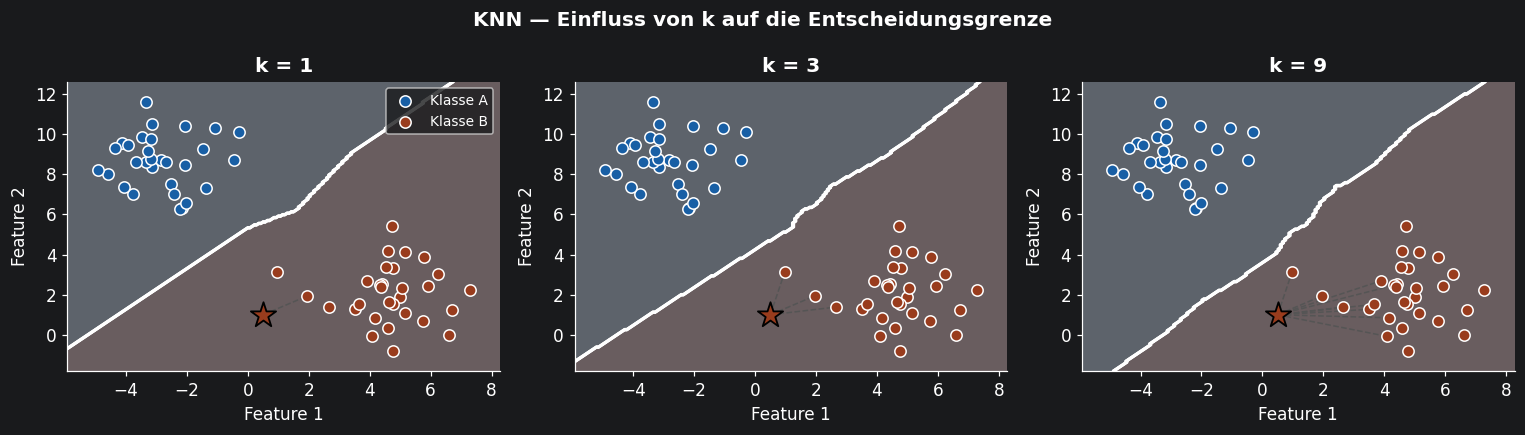

In [2]:
np.random.seed(42)
X, y = make_blobs(n_samples=60, centers=2, cluster_std=1.4, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('KNN — Einfluss von k auf die Entscheidungsgrenze', fontweight='bold')

cmap_light = ListedColormap(['#DDEEFF', '#FFDDDD'])
cmap_bold  = ListedColormap([BLAU, ROT])

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

query = np.array([[0.5, 1.0]])

for ax, k in zip(axes, [1, 3, 9]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='white', linewidths=1.5)

    ax.scatter(X[y==0,0], X[y==0,1], c=BLAU, edgecolors='white', s=55, zorder=3, label='Klasse A')
    ax.scatter(X[y==1,0], X[y==1,1], c=ROT,  edgecolors='white', s=55, zorder=3, label='Klasse B')

    # Nachbarn einzeichnen
    dists, idxs = model.kneighbors(query)
    for i in idxs[0]:
        ax.plot([query[0,0], X[i,0]], [query[0,1], X[i,1]],
                color='#555', lw=1, ls='--', zorder=2)

    pred = model.predict(query)[0]
    farbe = BLAU if pred == 0 else ROT
    ax.scatter(*query[0], marker='*', s=300, c=farbe,
               edgecolors='black', lw=1.2, zorder=5)

    ax.set_title(f'k = {k}', fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if k == 1:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

---
## 2. Decision Tree — Baumstruktur
Jeder Knoten stellt eine Ja/Nein-Frage. Die Tiefe bestimmt die Komplexität.

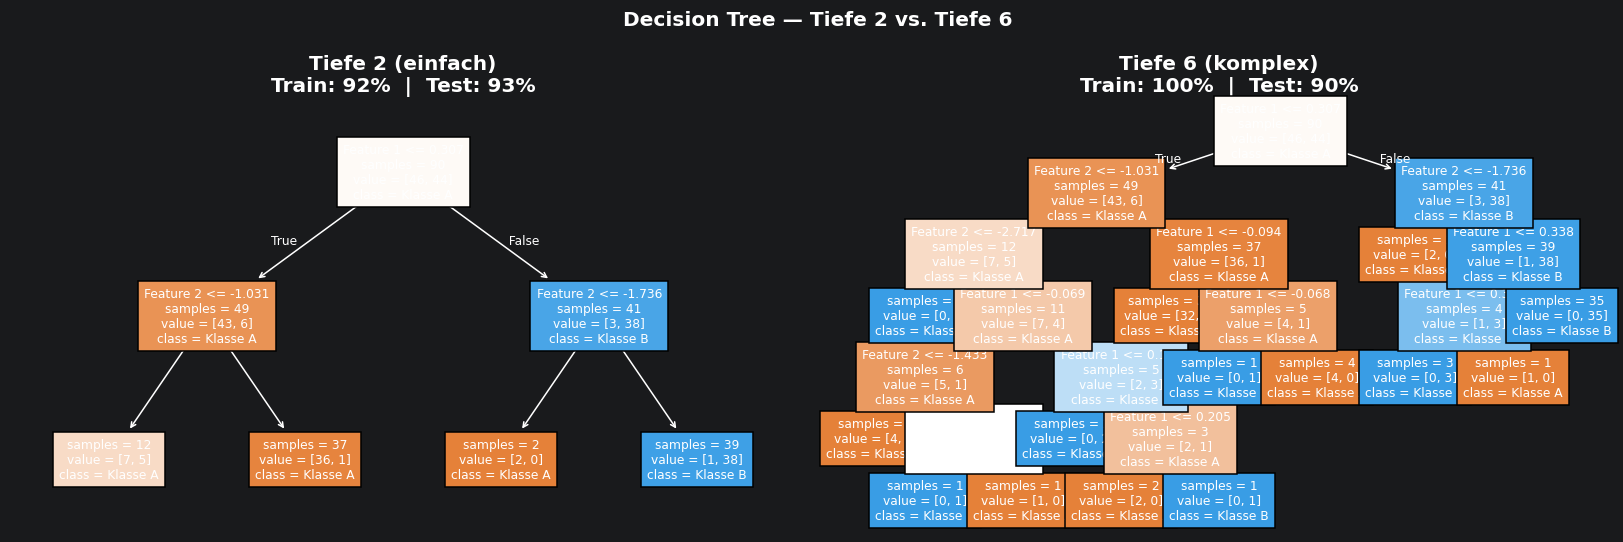

In [3]:
X2, y2 = make_classification(n_samples=120, n_features=2, n_informative=2,
                              n_redundant=0, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Decision Tree — Tiefe 2 vs. Tiefe 6', fontweight='bold')

for ax, depth, titel in zip(axes, [2, 6], ['Tiefe 2 (einfach)', 'Tiefe 6 (komplex)']):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X2_train, y2_train)
    acc_train = accuracy_score(y2_train, tree.predict(X2_train))
    acc_test  = accuracy_score(y2_test,  tree.predict(X2_test))

    plot_tree(tree, ax=ax, filled=True,
              feature_names=['Feature 1','Feature 2'],
              class_names=['Klasse A','Klasse B'],
              impurity=False, proportion=False,
              fontsize=8,
              node_ids=False)
    ax.set_title(f'{titel}\nTrain: {acc_train:.0%}  |  Test: {acc_test:.0%}', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Entscheidungsgrenzen — alle Modelle im Vergleich
Wie "denkt" jedes Modell? Die farbigen Flächen zeigen die Entscheidungsgebiete.

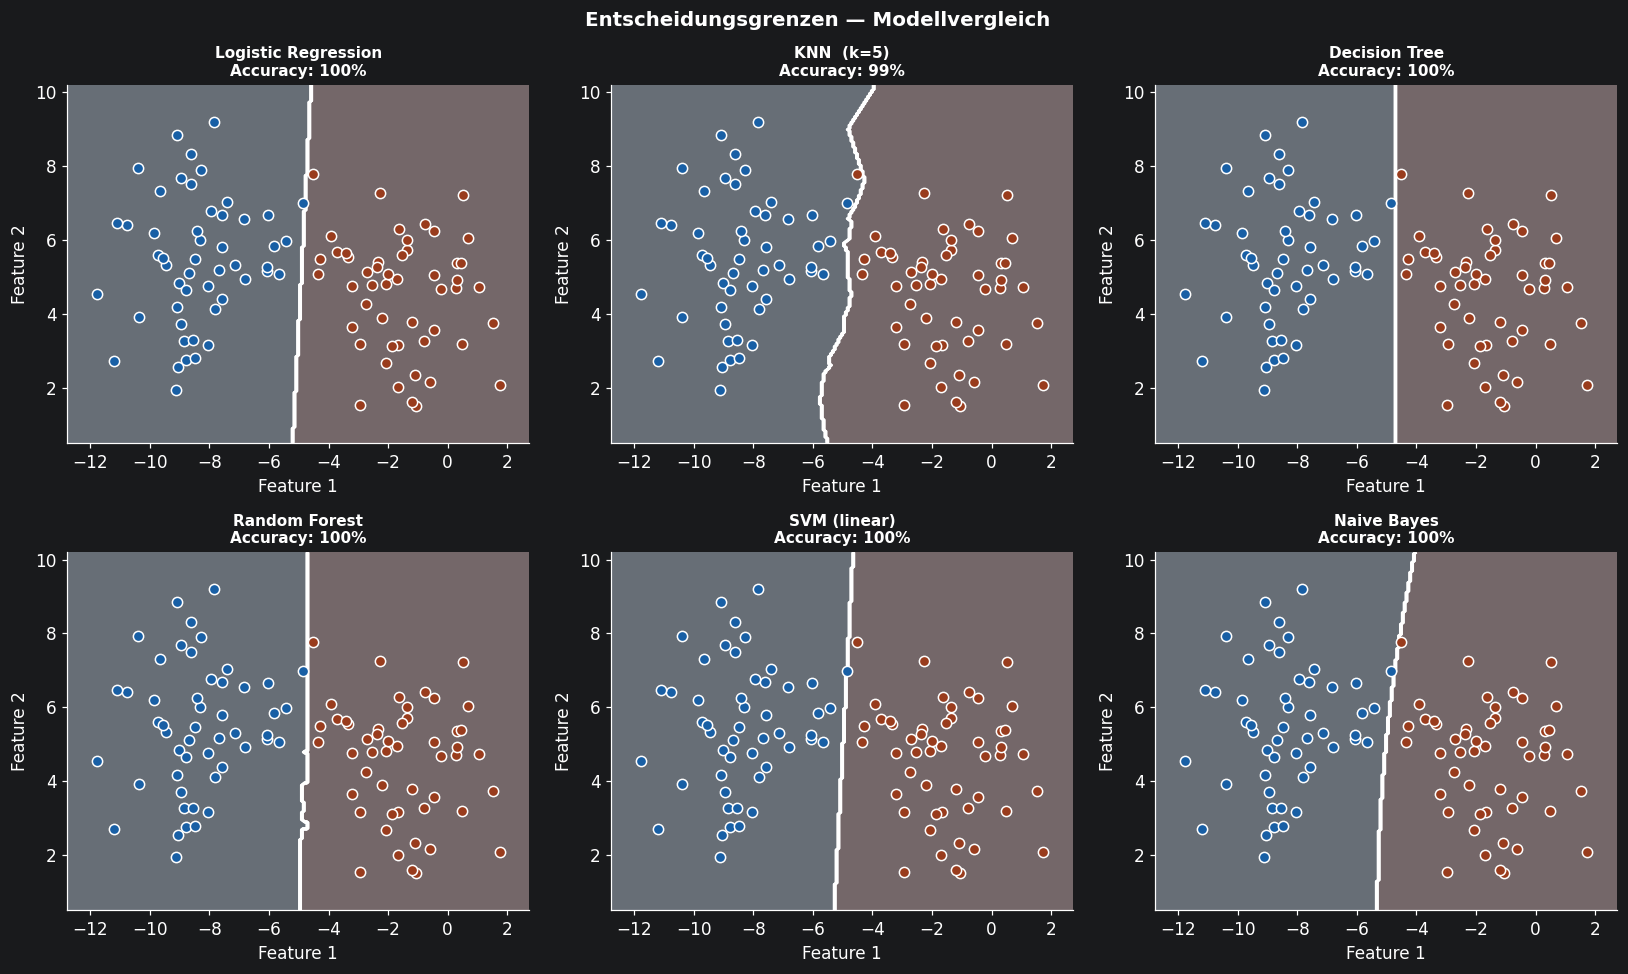

In [4]:
X3, y3 = make_blobs(n_samples=100, centers=2, cluster_std=1.6, random_state=7)

modelle = [
    ('Logistic Regression', LogisticRegression()),
    ('KNN  (k=5)',          KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('SVM (linear)',        SVC(kernel='linear', probability=True)),
    ('Naive Bayes',         GaussianNB()),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Entscheidungsgrenzen — Modellvergleich', fontweight='bold', fontsize=13)

x_min, x_max = X3[:,0].min()-1, X3[:,0].max()+1
y_min, y_max = X3[:,1].min()-1, X3[:,1].max()+1
xx3, yy3 = np.meshgrid(np.linspace(x_min,x_max,250), np.linspace(y_min,y_max,250))
cmap_l = ListedColormap(['#DDEEFF','#FFDDDD'])

for ax, (name, model) in zip(axes.ravel(), modelle):
    model.fit(X3, y3)
    Z = model.predict(np.c_[xx3.ravel(), yy3.ravel()]).reshape(xx3.shape)
    ax.contourf(xx3, yy3, Z, alpha=0.4, cmap=cmap_l)
    ax.contour(xx3, yy3, Z, colors='white', linewidths=1.5)
    ax.scatter(X3[y3==0,0], X3[y3==0,1], c=BLAU, edgecolors='white', s=45, zorder=3)
    ax.scatter(X3[y3==1,0], X3[y3==1,1], c=ROT,  edgecolors='white', s=45, zorder=3)
    acc = accuracy_score(y3, model.predict(X3))
    ax.set_title(f'{name}\nAccuracy: {acc:.0%}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

---
## 4. Overfitting & Underfitting
Train-Accuracy vs. Test-Accuracy bei steigender Modellkomplexität (Decision Tree Tiefe).

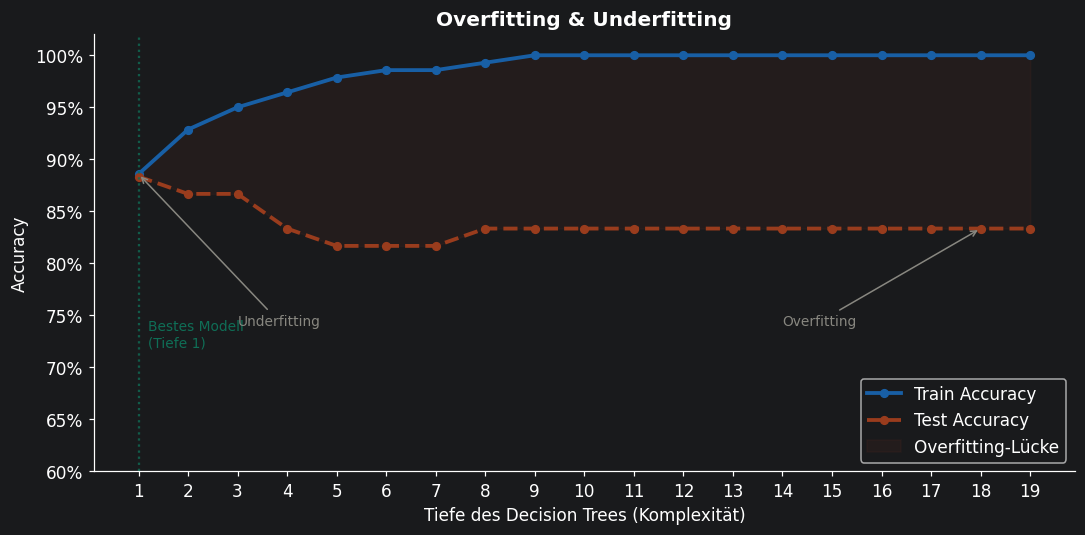

In [5]:
X4, y4 = make_classification(n_samples=200, n_features=2, n_informative=2,
                              n_redundant=0, random_state=1)
X4_tr, X4_te, y4_tr, y4_te = train_test_split(X4, y4, test_size=0.3, random_state=42)

depths = range(1, 20)
train_accs, test_accs = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X4_tr, y4_tr)
    train_accs.append(accuracy_score(y4_tr, m.predict(X4_tr)))
    test_accs.append(accuracy_score(y4_te, m.predict(X4_te)))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(depths, train_accs, color=BLAU,  lw=2.5, marker='o', ms=5, label='Train Accuracy')
ax.plot(depths, test_accs,  color=ROT,   lw=2.5, marker='o', ms=5, ls='--', label='Test Accuracy')

best_d = int(np.argmax(test_accs)) + 1
ax.axvline(best_d, color=GRUEN, lw=1.5, ls=':', alpha=0.8)
ax.text(best_d+0.2, 0.72, f'Bestes Modell\n(Tiefe {best_d})', color=GRUEN, fontsize=9)

ax.annotate('Underfitting', xy=(1, train_accs[0]), xytext=(3, 0.74),
            arrowprops=dict(arrowstyle='->', color=GRAU), color=GRAU, fontsize=9)
ax.annotate('Overfitting', xy=(18, test_accs[17]), xytext=(14, 0.74),
            arrowprops=dict(arrowstyle='->', color=GRAU), color=GRAU, fontsize=9)

ax.fill_between(depths, train_accs, test_accs,
                where=[t > v for t,v in zip(train_accs, test_accs)],
                alpha=0.08, color=ROT, label='Overfitting-Lücke')

ax.set_xlabel('Tiefe des Decision Trees (Komplexität)')
ax.set_ylabel('Accuracy')
ax.set_title('Overfitting & Underfitting', fontweight='bold')
ax.set_ylim(0.6, 1.02)
ax.set_xticks(list(depths))
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
plt.tight_layout()
plt.show()

---
## 5. Random Forest — Ein Baum vs. viele Bäume
Einzelner Decision Tree vs. Random Forest: stabiler durch Mehrheitsentscheid.

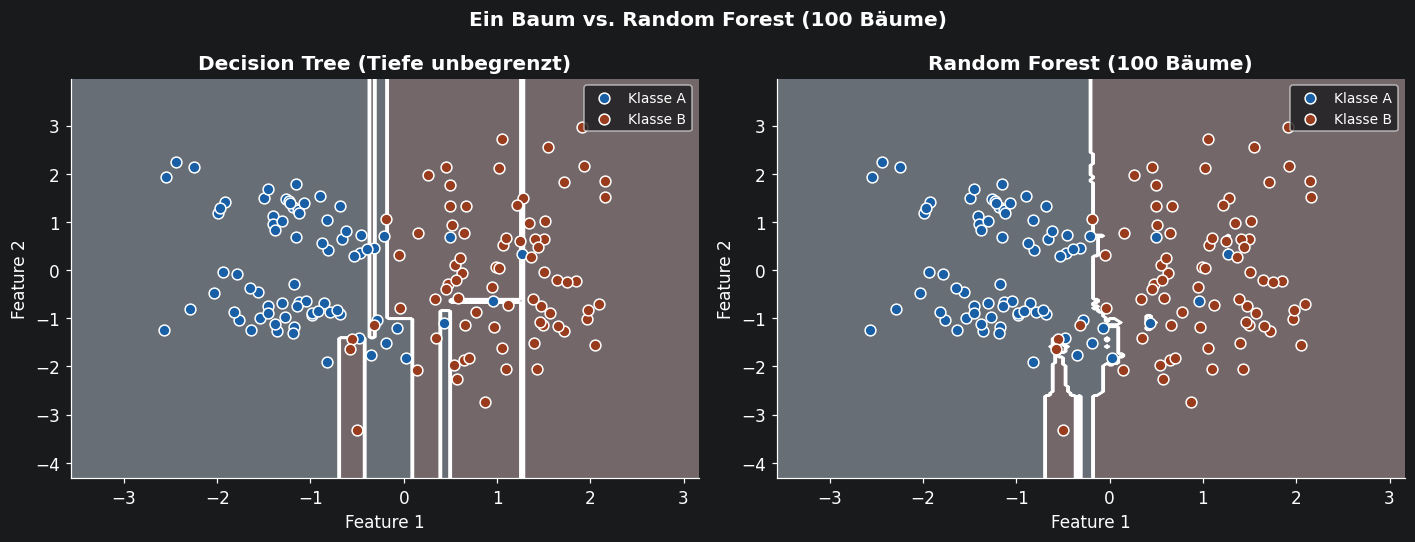

In [6]:
X5, y5 = make_classification(n_samples=150, n_features=2, n_informative=2,
                              n_redundant=0, random_state=99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ein Baum vs. Random Forest (100 Bäume)', fontweight='bold')

x_min, x_max = X5[:,0].min()-1, X5[:,0].max()+1
y_min, y_max = X5[:,1].min()-1, X5[:,1].max()+1
xx5, yy5 = np.meshgrid(np.linspace(x_min,x_max,250), np.linspace(y_min,y_max,250))
cmap_l2 = ListedColormap(['#DDEEFF','#FFDDDD'])

for ax, (name, model) in zip(axes, [
    ('Decision Tree (Tiefe unbegrenzt)', DecisionTreeClassifier(random_state=42)),
    ('Random Forest (100 Bäume)',        RandomForestClassifier(n_estimators=100, random_state=42)),
]):
    model.fit(X5, y5)
    Z = model.predict(np.c_[xx5.ravel(), yy5.ravel()]).reshape(xx5.shape)
    ax.contourf(xx5, yy5, Z, alpha=0.4, cmap=cmap_l2)
    ax.contour(xx5, yy5, Z, colors='white', linewidths=1)
    ax.scatter(X5[y5==0,0], X5[y5==0,1], c=BLAU, edgecolors='white', s=50, zorder=3, label='Klasse A')
    ax.scatter(X5[y5==1,0], X5[y5==1,1], c=ROT,  edgecolors='white', s=50, zorder=3, label='Klasse B')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Feature Importance — Random Forest
Welche Merkmale sind für die Entscheidung am wichtigsten?

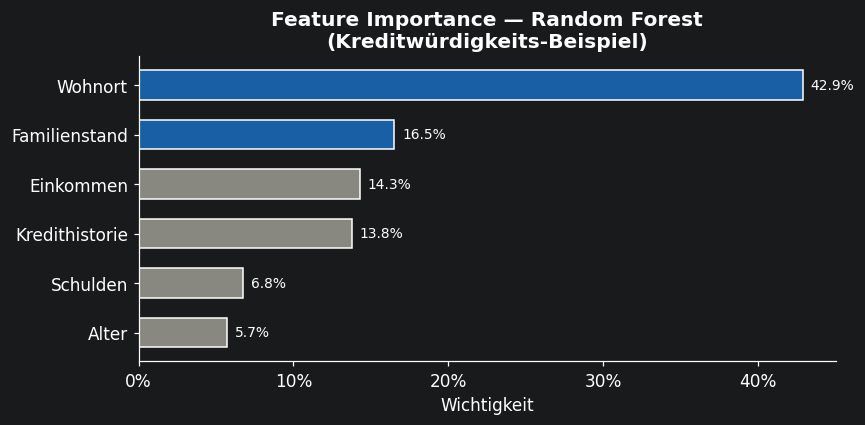

In [7]:
X6, y6 = make_classification(n_samples=300, n_features=6, n_informative=3,
                              n_redundant=1, random_state=42)
feature_names = ['Alter', 'Einkommen', 'Schulden', 'Kredithistorie', 'Wohnort', 'Familienstand']

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X6, y6)

importances = rf.feature_importances_
order = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh([feature_names[i] for i in order], importances[order],
               color=[BLAU if importances[i] > 0.15 else GRAU for i in order],
               edgecolor='white', height=0.6)

for bar, val in zip(bars, importances[order]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

ax.set_xlabel('Wichtigkeit')
ax.set_title('Feature Importance — Random Forest\n(Kreditwürdigkeits-Beispiel)', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
plt.tight_layout()
plt.show()

---
## 7. Modellvergleich — Accuracy auf denselben Daten

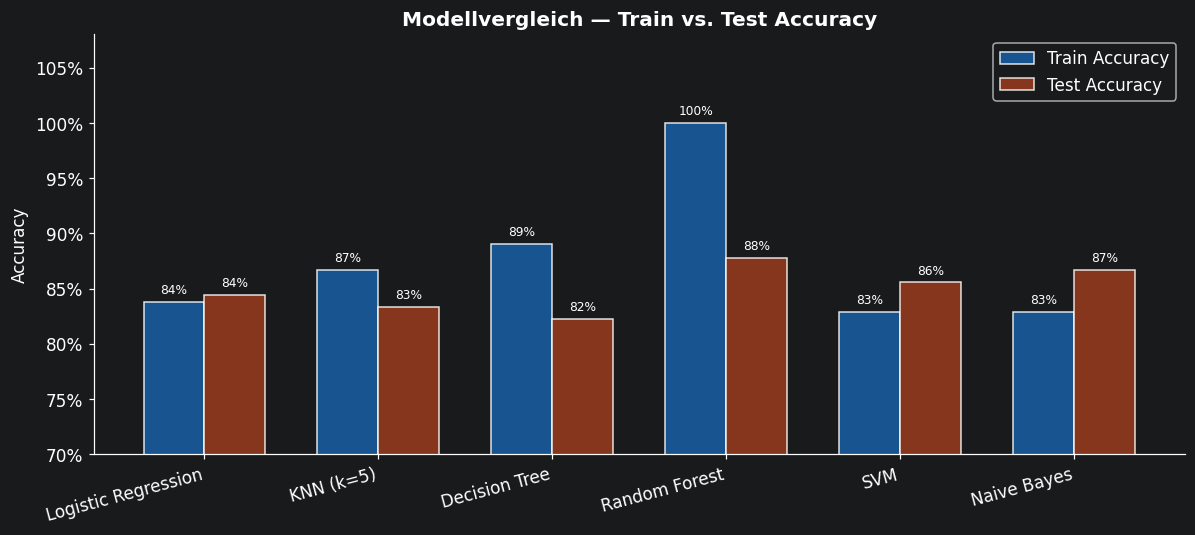

In [8]:
X7, y7 = make_classification(n_samples=300, n_features=4, n_informative=3,
                              n_redundant=0, random_state=42)
X7_tr, X7_te, y7_tr, y7_te = train_test_split(X7, y7, test_size=0.3, random_state=42)

modelle2 = [
    ('Logistic Regression', LogisticRegression()),
    ('KNN (k=5)',           KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('SVM',                 SVC(kernel='linear')),
    ('Naive Bayes',         GaussianNB()),
]

namen, train_sc, test_sc = [], [], []
for name, m in modelle2:
    m.fit(X7_tr, y7_tr)
    namen.append(name)
    train_sc.append(accuracy_score(y7_tr, m.predict(X7_tr)))
    test_sc.append(accuracy_score(y7_te, m.predict(X7_te)))

x = np.arange(len(namen))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, train_sc, w, label='Train Accuracy', color=BLAU, alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, test_sc,  w, label='Test Accuracy',  color=ROT,  alpha=0.85, edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(namen, rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.7, 1.08)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_title('Modellvergleich — Train vs. Test Accuracy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()